##Acsses token to clone repo


In [11]:
from google.colab import userdata

token = userdata.get('github_mask')


In [12]:
!git clone https://{token}@github.com/Aliaa-mohamed47/face-mask-detection.git

Cloning into 'face-mask-detection'...
remote: Enumerating objects: 11685, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 11685 (delta 17), reused 3 (delta 1), pack-reused 11643 (from 3)
Receiving objects: 100% (11685/11685), 330.80 MiB | 33.96 MiB/s, done.
Resolving deltas: 100% (18/18), done.
Updating files: 100% (11802/11802), done.


In [13]:
!ls

face-mask-detection  sample_data


In [14]:
%cd face-mask-detection
!ls data/train

/content/face-mask-detection
WithMask  WithoutMask


 ## Install & imports

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
import os


## Device

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
## Paths

In [17]:
DATA_DIR = "/content/face-mask-detection/data"
BATCH_SIZE = 32
IMG_SIZE = 224


##  Transforms (THIS is where augmentation is used correctly)

In [18]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


##  Datasets & Loaders

In [20]:
train_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "train"),
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "val"),
    transform=val_test_transforms
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "test"),
    transform=val_test_transforms
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_dataset.classes
print("Classes:", class_names)


Classes: ['WithMask', 'WithoutMask']


## MobileNetV2 (Transfer Learning)


In [21]:
model = models.mobilenet_v2(pretrained=True)

# Freeze backbone
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier
model.classifier[1] = nn.Linear(model.last_channel, 2)

model = model.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 157MB/s]


## Loss & Optimizer

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
## Training Loop

In [24]:
EPOCHS = 10

train_acc, val_acc = [], []
train_loss, val_loss = [], []

best_val_acc = 0.0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # ---------- TRAIN ----------
    model.train()
    running_loss = 0
    correct = total = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_train_acc = correct / total
    train_acc.append(epoch_train_acc)
    train_loss.append(running_loss / len(train_loader))

    # ---------- VAL ----------
    model.eval()
    running_loss = 0
    correct = total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_val_acc = correct / total
    val_acc.append(epoch_val_acc)
    val_loss.append(running_loss / len(val_loader))

    print(f"Train Acc: {epoch_train_acc:.4f} | Val Acc: {epoch_val_acc:.4f}")

    # Save best model
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), "mask_detector.pth")



Epoch 1/10


100%|██████████| 313/313 [01:05<00:00,  4.75it/s]


Train Acc: 0.9259 | Val Acc: 0.9637

Epoch 2/10


100%|██████████| 313/313 [01:03<00:00,  4.93it/s]


Train Acc: 0.9653 | Val Acc: 0.9812

Epoch 3/10


...

Train Acc: 0.9788 | Val Acc: 0.9938

Epoch 9/10


100%|██████████| 313/313 [01:01<00:00,  5.10it/s]


Train Acc: 0.9801 | Val Acc: 0.9925

Epoch 10/10


100%|██████████| 313/313 [01:01<00:00,  5.09it/s]


Train Acc: 0.9808 | Val Acc: 0.9925


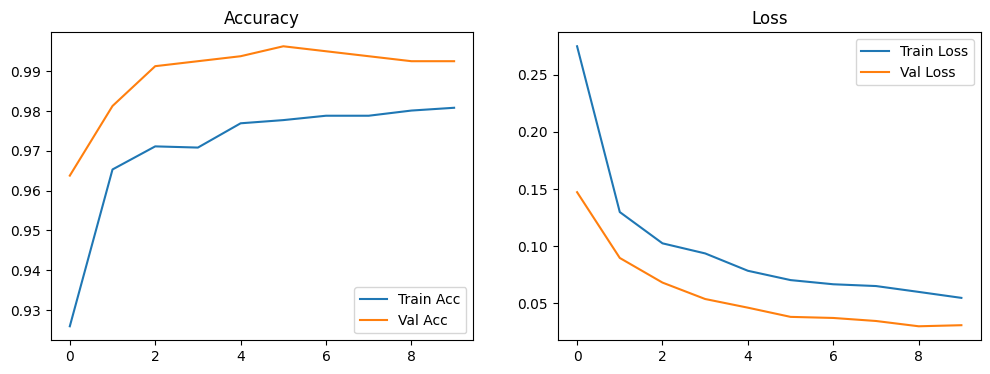

In [26]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_acc, label="Train Acc")
plt.plot(val_acc, label="Val Acc")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.title("Loss")
plt.legend()

plt.show()


In [27]:
!ls -lh

total 8.8M
drwxr-xr-x 2 root root 4.0K Apr 21 12:22 api
drwxr-xr-x 5 root root 4.0K Apr 21 12:22 data
-rw-r--r-- 1 root root 8.8M Apr 21 12:35 mask_detector.pth
drwxr-xr-x 2 root root 4.0K Apr 21 12:22 notebooks
-rw-r--r-- 1 root root   21 Apr 21 12:22 README.md


In [28]:
!mkdir -p model
!mv mask_detector.pth model/mask_detector.pth
!ls model

mask_detector.pth


In [ ]:
from google.colab import userdata
token = userdata.get('github_mask')

In [32]:
!git config --global user.email "alaakamal7957358@gmail.com"
!git config --global user.name "AlaaKamalFaroq"

In [33]:
!git remote set-url origin https://{token}@github.com/Aliaa-mohamed47/face-mask-detection.git

In [34]:
!git add model/mask_detector.pth
!git commit -m "Add trained MobileNetV2 model"
!git push origin main

[main ab24cf3] Add trained MobileNetV2 model
 1 file changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 model/mask_detector.pth
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (4/4), 8.03 MiB | 7.92 MiB/s, done.
Total 4 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/Aliaa-mohamed47/face-mask-detection.git
   a05df8e..ab24cf3  main -> main


In [40]:
!git add /content/face-mask-detection/notebooks/4_model_training.ipynb

In [41]:
! git commit -m "pipline for trainning model"

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [42]:
! git push origin main

Everything up-to-date


In [43]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
